In [2]:
!pip install pandas matplotlib seaborn wordcloud

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/resumes_processed.csv")
print(f"Shape: {df.shape}")
print(f"\nCategories:\n{df['Category'].value_counts()}")

Shape: (13389, 15)

Categories:
Category
Education                    410
Electrical Engineering       384
Mechanical Engineer          384
Consultant                   368
Sales                        364
Civil Engineer               364
Management                   361
Human Resources              360
Digital Media                358
Accountant                   350
Java Developer               348
Operations Manager           345
Building and Construction    345
Testing                      344
Architecture                 344
Aviation                     340
Business Analyst             340
Finance                      339
SQL Developer                338
Public Relations             337
Health and Fitness           332
Arts                         332
Network Security Engineer    330
DotNet Developer             329
Apparel                      320
Banking                      314
Automobile                   313
Web Designing                309
SAP Developer                304
Da

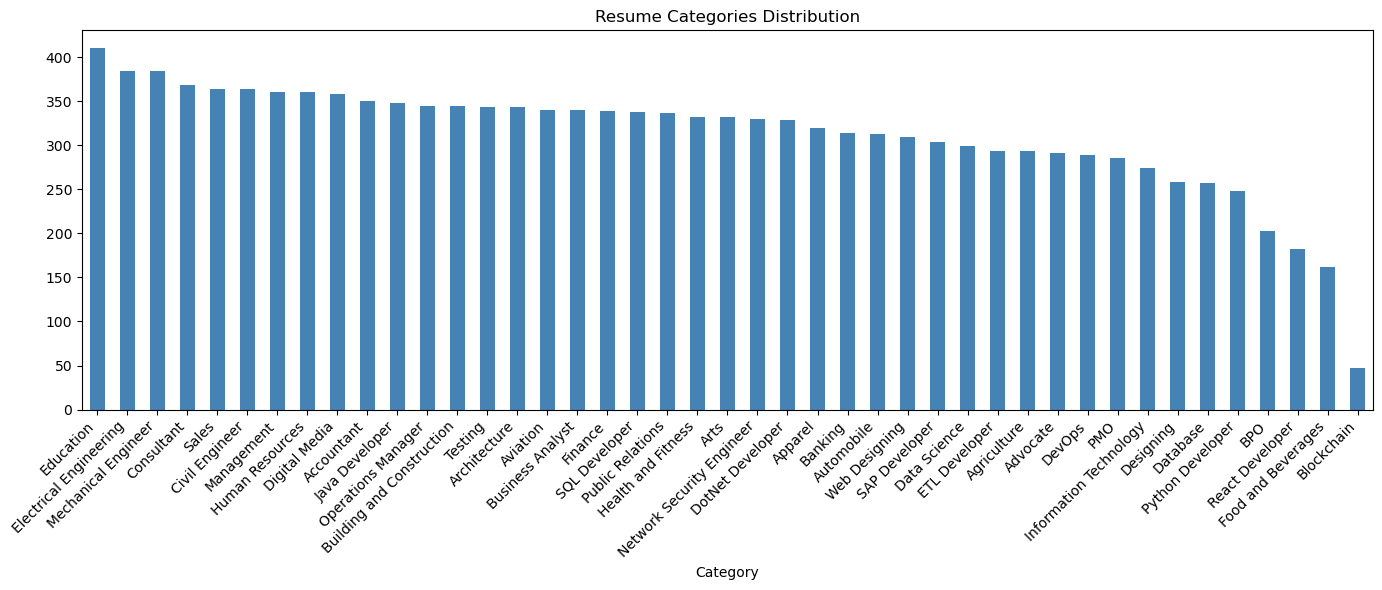

✅ Saved: category_distribution.png


In [7]:
plt.figure(figsize=(14, 6))
df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Resume Categories Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/category_distribution.png')
plt.show()
print("✅ Saved: category_distribution.png")

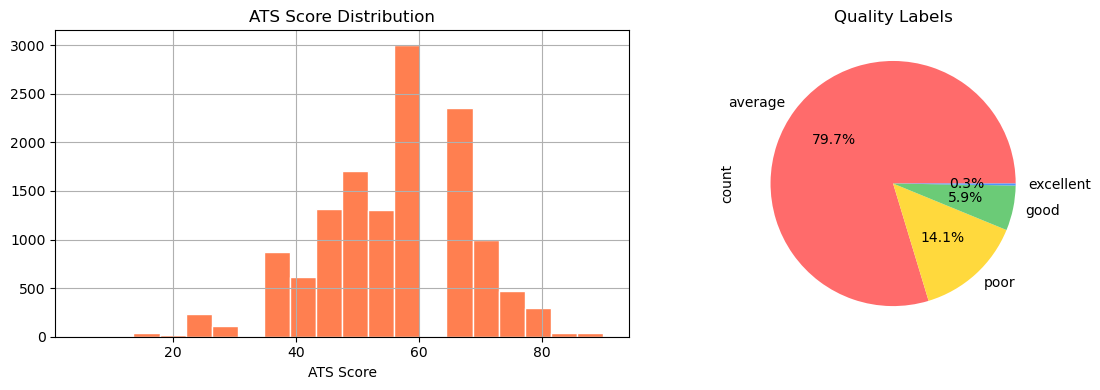

✅ Saved: ats_distribution.png


In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['ats_score'].hist(bins=20, color='coral', edgecolor='white')
plt.title('ATS Score Distribution')
plt.xlabel('ATS Score')

plt.subplot(1, 2, 2)
df['quality_label'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['#ff6b6b','#ffd93d','#6bcb77','#4d96ff'])
plt.title('Quality Labels')
plt.tight_layout()
plt.savefig('../data/processed/ats_distribution.png')
plt.show()
print("✅ Saved: ats_distribution.png")

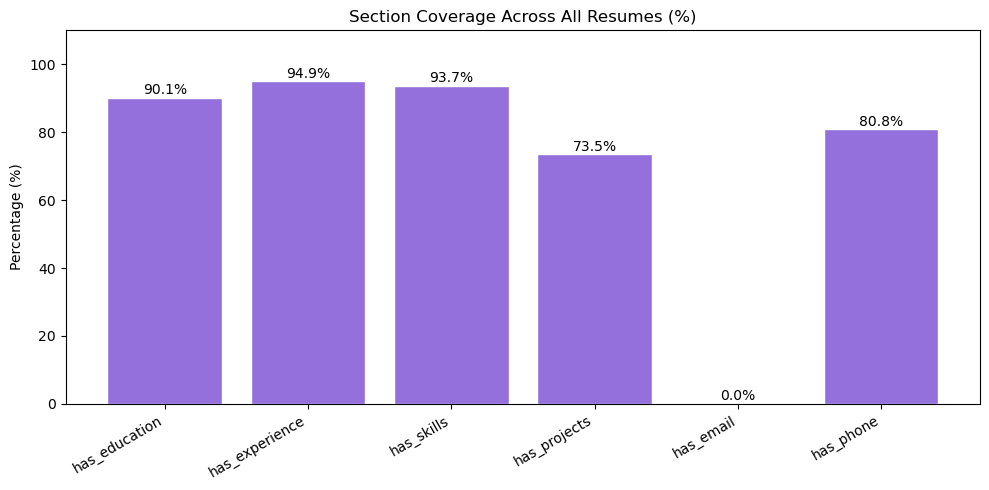

In [9]:
section_cols = ['has_education','has_experience','has_skills',
                'has_projects','has_email','has_phone']

coverage = {col: df[col].mean() * 100 for col in section_cols}

plt.figure(figsize=(10, 5))
plt.bar(coverage.keys(), coverage.values(), color='mediumpurple', edgecolor='white')
plt.title('Section Coverage Across All Resumes (%)')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Percentage (%)')
plt.ylim(0, 110)
for i, (k, v) in enumerate(coverage.items()):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/section_coverage.png')
plt.show()

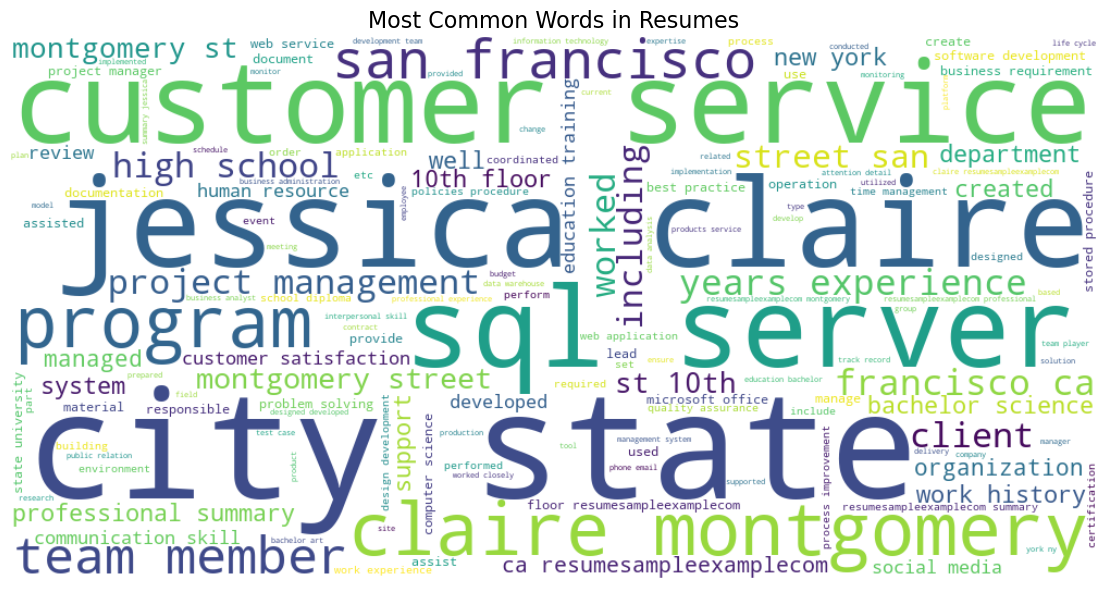

✅ Saved: wordcloud.png


In [10]:
from wordcloud import WordCloud

text = " ".join(df['Text'].dropna().tolist())
wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Resumes', fontsize=16)
plt.tight_layout()
plt.savefig('../data/processed/wordcloud.png')
plt.show()
print("✅ Saved: wordcloud.png")

In [11]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total Resumes    : {len(df):,}")
print(f"Total Categories : {df['Category'].nunique()}")
print(f"Avg Word Count   : {df['word_count'].mean():.0f}")
print(f"Avg ATS Score    : {df['ats_score'].mean():.1f}")
print(f"\nQuality Distribution:")
for label, count in df['quality_label'].value_counts().items():
    pct = count/len(df)*100
    print(f"  {label:10}: {count:5,} ({pct:.1f}%)")
print("\n✅ EDA Complete!")

DATASET SUMMARY
Total Resumes    : 13,389
Total Categories : 43
Avg Word Count   : 475
Avg ATS Score    : 55.9

Quality Distribution:
  average   : 10,668 (79.7%)
  poor      : 1,892 (14.1%)
  good      :   794 (5.9%)
  excellent :    35 (0.3%)

✅ EDA Complete!
